## Group Visualizations

Plots means and 95% confidence intervals across all subjects.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd

from src.config import PROCESSED_DATA_DIR

2026-05-07 19:26:07.303 | INFO     | src.config:<module>:11 - PROJ_ROOT path is: /Users/virginia/Desktop/GitHub/cycle-tracking/cycle-tracking


In [2]:
interday = pd.read_csv(PROCESSED_DATA_DIR / "features_interday.csv")
intraday = pd.read_csv(PROCESSED_DATA_DIR / "features_intraday.csv", parse_dates=["datetime"])

print(f"Interday: {interday.shape}  |  subjects: {interday['id'].nunique()}")
print(f"Intraday: {intraday.shape}")

Interday: (3270, 44)  |  subjects: 38
Intraday: (859104, 15)


In [3]:
PHASE_ORDER = ["Menstrual", "Follicular", "Fertility", "Luteal"]
PHASE_COLORS = {
    "Menstrual": "#d62728",
    "Follicular": "#1f77b4",
    "Fertility": "#2ca02c",
    "Luteal": "#9467bd",
}
REPORT_COLS = [
    "appetite", "exerciselevel", "headaches", "cramps", "sorebreasts",
    "fatigue", "sleepissue", "moodswing", "stress", "foodcravings",
    "indigestion", "bloating",
]

def ci95(series):
    n = series.count()
    if n < 2:
        return float("nan")
    return 1.96 * series.std() / np.sqrt(n)

### Cycle length and phase duration distributions

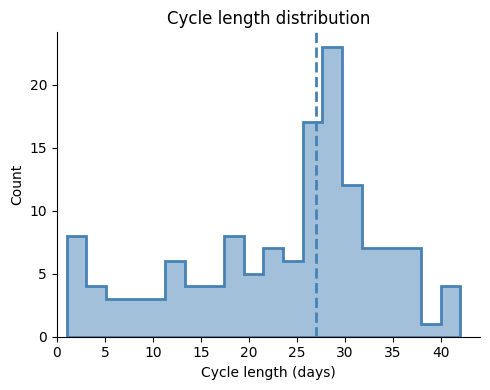

In [4]:
cycle_lengths = interday.groupby(["id", "cycle_id"])["cycle_day"].max()

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(cycle_lengths, bins=20, 
        histtype="stepfilled",
        facecolor=mcolors.to_rgba("steelblue", alpha=0.5),
        edgecolor="steelblue", 
        linewidth=2)
ax.axvline(cycle_lengths.median(), color="steelblue", linewidth=2, linestyle="--")
ax.set_xlabel("Cycle length (days)")
ax.set_ylabel("Count")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, None)
ax.set_title("Cycle length distribution")
fig.tight_layout()
plt.show()

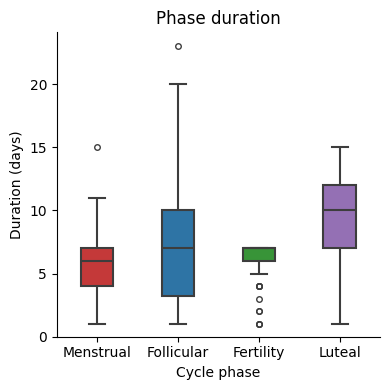

In [ ]:
phase_dur = (
    interday.dropna(subset=["phase"])
    .groupby(["id", "cycle_id", "phase"])
    .size()
    .reset_index(name="days")
)

fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(data=phase_dur, x="phase", y="days",
            hue="phase", palette=PHASE_COLORS, fill=True, saturation=0.8,
            linecolor="auto", linewidth=1.5, width=0.4, order=PHASE_ORDER,
            flierprops={"markersize": 4})

ax.set_xlabel("Cycle phase")
ax.set_ylabel("Duration (days)")
ax.set_ylim(0, None)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Phase duration")
fig.tight_layout()
plt.show()

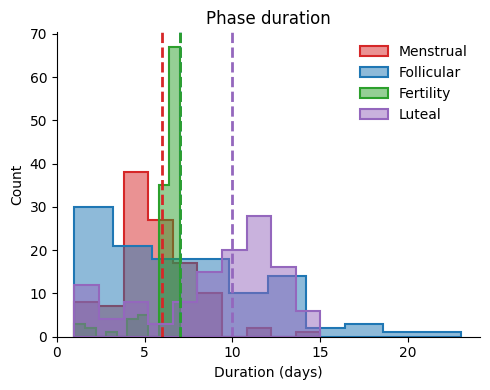

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))

for phase in PHASE_ORDER:
    data = phase_dur[phase_dur["phase"] == phase]["days"]
    color = PHASE_COLORS[phase]
    ax.hist(data, histtype="stepfilled",
            facecolor=mcolors.to_rgba(color, alpha=0.5),
            edgecolor=color, linewidth=1.5, label=phase)
    ax.axvline(data.median(), color=color, linewidth=2, linestyle="--")

ax.set_xlabel("Duration (days)")
ax.set_ylabel("Count")
ax.set_xlim(0, None)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Phase duration")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


### Hormones across study days and cycle progression

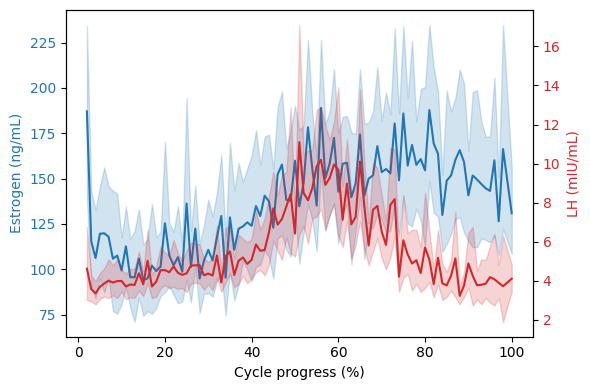

In [17]:
df = interday.dropna(subset=["estrogen_smooth", "lh_smooth"]).copy()
df["pct_bin"] = df["cycle_pct"].round(0).astype(int)
by_pct = (
    df.groupby(["id", "pct_bin"])[["estrogen_smooth", "lh_smooth"]]
    .mean()
    .reset_index()
)
fig, ax1 = plt.subplots(figsize=(6, 4))
ax2 = ax1.twinx()

sns.lineplot(data=by_pct, x="pct_bin", y="estrogen_smooth", ax=ax1, color="tab:blue")
sns.lineplot(data=by_pct, x="pct_bin", y="lh_smooth", ax=ax2, color="tab:red")
ax1.set_ylabel("Estrogen (ng/mL)", color="tab:blue")                                                                    
ax2.set_ylabel("LH (mIU/mL)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:red")  
ax1.set_xlabel("Cycle progress (%)")

fig.tight_layout()
plt.show()

### Heart rate and glucose across day by cycle phase

### Report scores by cycle phase

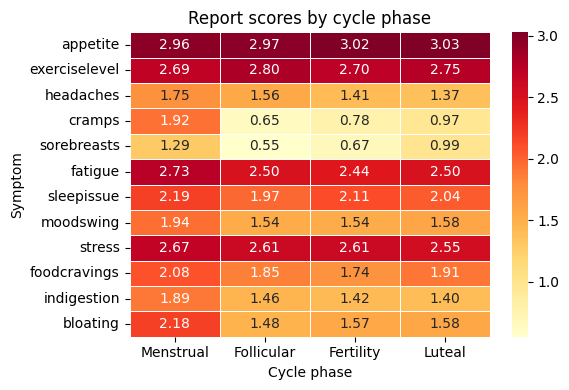

In [22]:
df = interday.dropna(subset=["phase"]).copy()
phase_means = df.groupby("phase")[REPORT_COLS].mean().reindex(PHASE_ORDER)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(phase_means.T, ax=ax, cmap="YlOrRd", annot=True, fmt=".2f", linewidths=0.5)
ax.set_xlabel("Cycle phase")
ax.set_ylabel("Symptom")
ax.set_title("Report scores by cycle phase")
fig.tight_layout()
plt.show()

### Sleep metrics by cycle phase

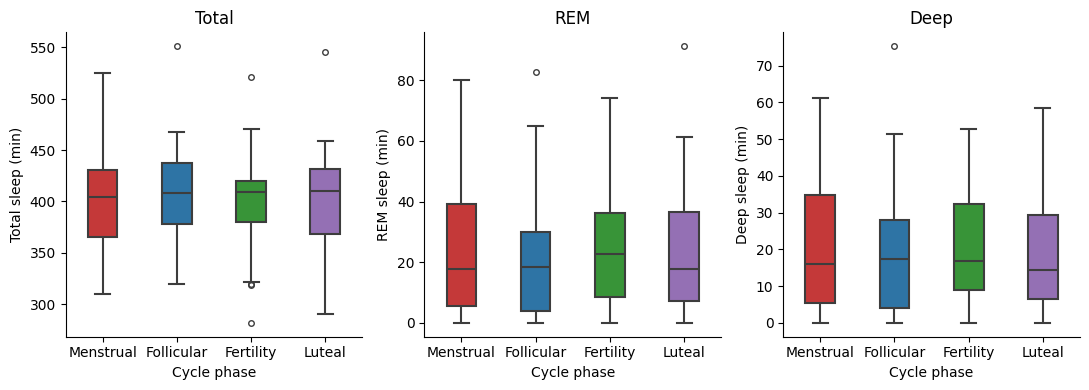

In [44]:
df = interday.dropna(subset=["phase"]).copy()
sleep_vars = ["sleep_min_total", "sleep_min_rem", "sleep_min_deep"]
ylabels = ["Total sleep (min)", "REM sleep (min)", "Deep sleep (min)"]

fig, axes = plt.subplots(1, 3, figsize=(11, 4))

for ax, var, ylabel in zip(axes, sleep_vars, ylabels):
    data = df.groupby(["id", "phase"])[[var]].mean()
    sns.boxplot(data=data, x="phase", y=var,
            hue="phase", palette=PHASE_COLORS, fill=True, saturation=0.8,
            linecolor="auto", linewidth=1.5, width=0.4, order=PHASE_ORDER,
            flierprops={"markersize": 4}, ax=ax)    
    ax.set_xlabel("Cycle phase")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel.split()[0])
    ax.tick_params(axis="x")
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()